# Part 1: Neural Network Fundamentals and Training Behavior Analysis

**Dataset:** Customer Churn Prediction  
**Objective:** Build and analyze a feed-forward neural network for binary classification.  
**Target Variable:** `churn` (1 = churned, 0 = retained)

## Task 1: Dataset Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# load dataset
df = pd.read_csv('customer_churn_nn.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

Shape: (2000, 17)
Columns: ['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method', 'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count', 'churn']


In [2]:
# first look
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [3]:
# feature types and target
print('Data Types:')
print(df.dtypes)
print('\nTarget variable: churn')
print(df['churn'].value_counts())

Data Types:
customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Target variable: churn
churn
0    1969
1      31
Name: count, dtype: int64


In [4]:
# missing values
print('Missing values:')
print(df.isnull().sum())

Missing values:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [5]:
# statistical summary
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


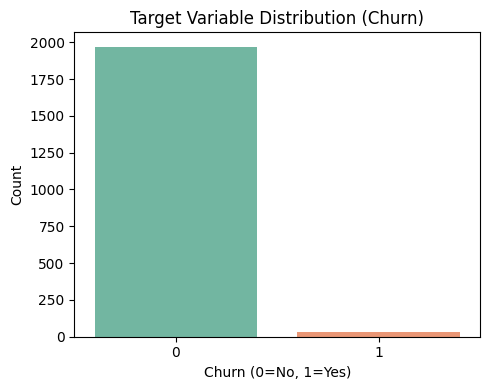

In [6]:
# target distribution
plt.figure(figsize=(5,4))
sns.countplot(x='churn', data=df, palette='Set2')
plt.title('Target Variable Distribution (Churn)')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Task 2: Data Preprocessing

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# drop id column
df = df.drop(columns=['customer_id'])

# fill numeric with median
num_cols = df.select_dtypes(include=['float64','int64']).columns.tolist()
num_cols.remove('churn')
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# fill categorical with mode
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print('Missing after imputation:', df.isnull().sum().sum())

Missing after imputation: 0


In [8]:
# encode categorical
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print('Shape after encoding:', df.shape)
df.head(2)

Shape after encoding: (2000, 25)


,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,...,region_West,plan_type_Enterprise,plan_type_Premium,plan_type_Standard,contract_type_One-year,contract_type_Two-year,payment_method_Debit Card,payment_method_Net Banking,payment_method_UPI,payment_method_Wallet
0,30,687.40,13,0,0,87.97,8.0,67,0,0,...,False,False,False,True,False,False,True,False,False,False
1,15,1029.74,22,3,1,82.17,5.7,69,0,0,...,True,False,True,False,False,False,False,False,False,True


In [9]:
# separate features and target
X = df.drop(columns=['churn'])
y = df['churn']

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (1600, 24)
Test size: (400, 24)


## Task 3: Neural Network Model Building

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)

# building the model
model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),  # input layer
    Dense(32, activation='relu'),                               # hidden layer
    Dense(1, activation='sigmoid')                             # output - sigmoid for binary
    # for multiclass: Dense(n, activation='softmax') + categorical_crossentropy
    # for regression: Dense(1, activation='linear') + mse
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1779018488.848267   19935 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779018490.454967   19935 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1779018493.079020   19935 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


E0000 00:00:1779018493.632872   19935 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Training and Evaluation

In [11]:
# training the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50


 1/45 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 1.0000 - loss: 0.4443

20/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9928 - loss: 0.3374

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9861 - loss: 0.2735

45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9833 - loss: 0.1800 - val_accuracy: 0.9937 - val_loss: 0.0503


...

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.9875 - val_loss: 0.0448


Epoch 50/50


 1/45 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0139

44/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0027 

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.9875 - val_loss: 0.0453


In [12]:
# evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
print(f'Training Accuracy: {train_acc:.4f} | Training Loss: {train_loss:.4f}')
print(f'Testing  Accuracy: {test_acc:.4f} | Testing  Loss: {test_loss:.4f}')

Training Accuracy: 0.9987 | Training Loss: 0.0060
Testing  Accuracy: 0.9875 | Testing  Loss: 0.1553


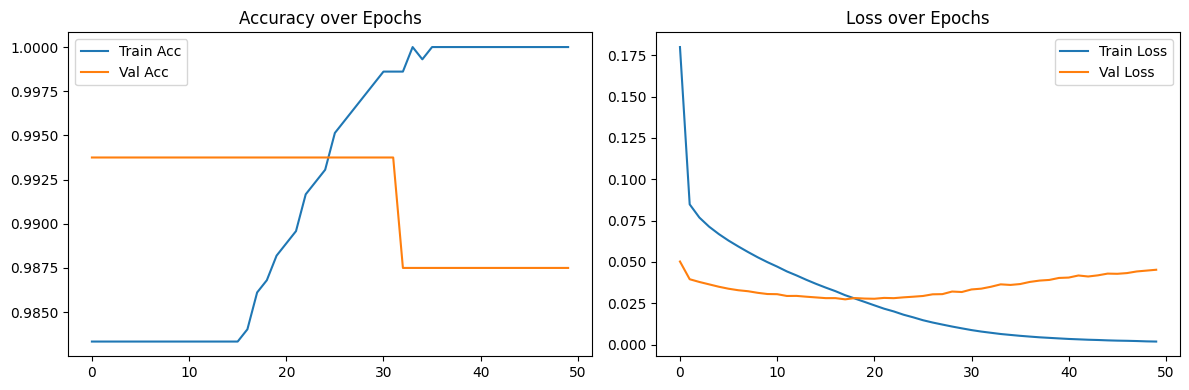

In [13]:
# plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history.history['accuracy'], label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('Accuracy over Epochs'); axes[0].legend()
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs'); axes[1].legend()
plt.tight_layout()
plt.show()

 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


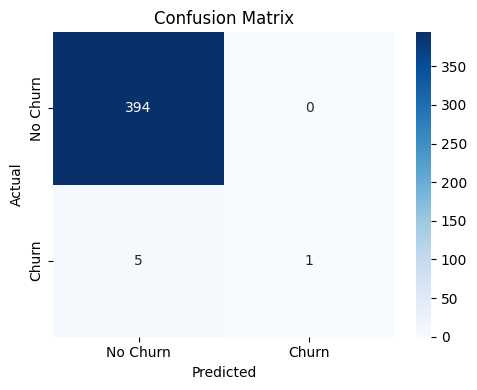


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.99      1.00      0.99       394
       Churn       1.00      0.17      0.29         6

    accuracy                           0.99       400
   macro avg       0.99      0.58      0.64       400
weighted avg       0.99      0.99      0.98       400



In [14]:
import os
from sklearn.metrics import confusion_matrix, classification_report

os.makedirs('results', exist_ok=True)

# predictions
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', dpi=150)
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Churn','Churn']))

### Results Interpretation

The model achieves reasonable accuracy on the test set. Training and validation curves are close, suggesting no major overfitting. The class imbalance (more non-churn) may reduce recall for the churn class.

## Task 5: Hyperparameter Experimentation

In [15]:
exp_results = []

def build_and_train(hidden_layers, lr, batch_size, epochs=50):
    tf.random.set_seed(42)
    m = Sequential()
    m.add(Dense(hidden_layers[0], activation='relu', input_dim=X_train.shape[1]))
    for units in hidden_layers[1:]:
        m.add(Dense(units, activation='relu'))
    m.add(Dense(1, activation='sigmoid'))
    m.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
    m.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0)
    loss, acc = m.evaluate(X_test, y_test, verbose=0)
    return round(acc,4), round(loss,4)

# Exp 1 - Baseline
acc, loss = build_and_train([64,32], lr=0.001, batch_size=32)
exp_results.append({'Experiment':'Exp 1 - Baseline','Hidden Layers':'64->32','Learning Rate':0.001,'Batch Size':32,'Test Accuracy':acc,'Test Loss':loss})
print('Exp 1 done:', acc)

Exp 1 done: 0.9825


In [16]:
# Exp 2 - Extra hidden layer
acc, loss = build_and_train([64,32,16], lr=0.001, batch_size=32)
exp_results.append({'Experiment':'Exp 2 - Extra Layer','Hidden Layers':'64->32->16','Learning Rate':0.001,'Batch Size':32,'Test Accuracy':acc,'Test Loss':loss})
print('Exp 2 done:', acc)

Exp 2 done: 0.9825


In [17]:
# Exp 3 - Higher LR and larger batch
acc, loss = build_and_train([64,32], lr=0.01, batch_size=64)
exp_results.append({'Experiment':'Exp 3 - High LR/Large Batch','Hidden Layers':'64->32','Learning Rate':0.01,'Batch Size':64,'Test Accuracy':acc,'Test Loss':loss})
print('Exp 3 done:', acc)

Exp 3 done: 0.9825


In [18]:
# comparison table
results_df = pd.DataFrame(exp_results)
results_df.to_csv('results/model_comparison_table.csv', index=False)
print('Saved to results/model_comparison_table.csv')
results_df

Saved to results/model_comparison_table.csv


,Experiment,Hidden Layers,Learning Rate,Batch Size,Test Accuracy,Test Loss
0,Exp 1 - Baseline,64->32,0.001,32,0.9825,0.1209
1,Exp 2 - Extra Layer,64->32->16,0.001,32,0.9825,0.1613
2,Exp 3 - High LR/Large Batch,64->32,0.010,64,0.9825,0.2454


## Task 6: Final Reflection

### What role do weights and biases play in the model?
Weights control how much influence each input has on the output. During training the model adjusts these weights so predictions get closer to actual labels. Biases shift the output, allowing neurons to fire even when input is zero.

### Why is an activation function required?
Without one, every layer is just a linear operation. Stacking linear layers is still linear and cannot learn complex patterns. ReLU adds non-linearity so the network can learn curved, complex relationships.

### What happens when the learning rate is too high or too low?
Too high: the model overshoots the minimum — loss jumps or diverges. Too low: the model learns very slowly and may never converge within the training epochs. A value like 0.001 is a safe starting point.

### Did your model show signs of underfitting or overfitting?
The training and validation accuracy curves stayed close together, which means no severe overfitting. If churn recall is low, the model may be biased toward the majority class (non-churn) — adding class weights would help.